In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.inspection import permutation_importance
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

In [24]:
model = joblib.load('../app/data/hospital_closure_model.pkl')
test = pd.read_csv('../data/test_data_with_pred.csv')
hospitals_full = pd.read_csv('../data/hospitals_full.csv')
hospitals_master = pd.read_csv('../data/hospitals_master.csv')
surv_functions = pd.read_csv('../data/surv_functions.csv')

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_61849/4197150820.py:3: DtypeWarning: Columns (67) have mixed types. Specify dtype option on import or set low_memory=False.
  hospitals_full = pd.read_csv('../data/hospitals_full.csv')


In [30]:
test['CCN'] = test['CCN'].astype(int).astype(str).str.zfill(6)

In [31]:
# Merge hospitals master with test data to bring back in identifying characteristics like hospital name
test_full = hospitals_master[['CCN','Facility Name','Prior Name','State','Closure Date']].merge(test, how='right', on='CCN')

In [32]:
test_full.head(2)

,CCN,Facility Name,Prior Name,State,Closure Date,Year,Medicaid charges,STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29),"ADJUSTED SALARIES, Subtotal Salaries",BALANCE SHEET: Prepaid expenses (G_C1THRU4_8),...,Hospital Type_Tribal,Hospital Type_Voluntary non-profit - Church,Hospital Type_Voluntary non-profit - Other,Hospital Type_Voluntary non-profit - Private,General Ownership Type_for-profit,General Ownership Type_govt,General Ownership Type_non-profit,Pred_Closure,Status,Time
0,190044,ACADIA GENERAL HOSPITAL,NaN,LA,NaN,2022,-0.141395,-0.291649,-0.496079,-0.494961,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.511800,False,16.0
1,190044,ACADIA GENERAL HOSPITAL,NaN,LA,NaN,2023,-0.244175,0.035763,-0.464594,-0.445257,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.385207,False,16.0


Looking at survival function dataframe. Each value in the survival functions dataframe captures the probability that the given hospital will survive (remain open) beyond the year in the column.

In [35]:
surv_functions.columns = [2009 + int(float(col)) for col in surv_functions.columns]

In [46]:
surv_functions_full = pd.concat([test_full[['CCN','Facility Name','Year']], surv_functions], axis=1)
surv_functions_full.head(2)

,CCN,Facility Name,Year,2011,2012,2014,2015,2016,2020,2021,2022,2023,2024,2025,2026
0,190044,ACADIA GENERAL HOSPITAL,2022,0.999880,0.999759,0.999639,0.999518,0.999397,0.998913,0.998668,0.998668,0.998668,0.998668,0.998668,0.998668
1,190044,ACADIA GENERAL HOSPITAL,2023,0.999894,0.999788,0.999682,0.999575,0.999469,0.999043,0.998826,0.998826,0.998826,0.998826,0.998826,0.998826


In [45]:
surv_functions_full[surv_functions_full['Year']==2025][['Facility Name',2025]].sort_values(by=2025)

,Facility Name,2025
465,CARILION TAZEWELL COMMUNITY HOSPITAL,0.898388
1600,MARION REGIONAL MEDICAL CENTER,0.985428
940,FAYETTE MEDICAL CENTER,0.994239
2959,UNION MEDICAL CENTER,0.994944
1101,GREENE COUNTY HOSPITAL,0.995450
...,...,...
1961,NANTUCKET COTTAGE HOSPITAL,0.999051
1295,HUGH CHATHAM MEMORIAL HOSPITAL,0.999054
1686,MCLEOD MEDICAL CENTER - DILLON,0.999057
1065,GRADY GENERAL HOSPITAL,0.999094


Examining risk scores (Pred_Closure column):

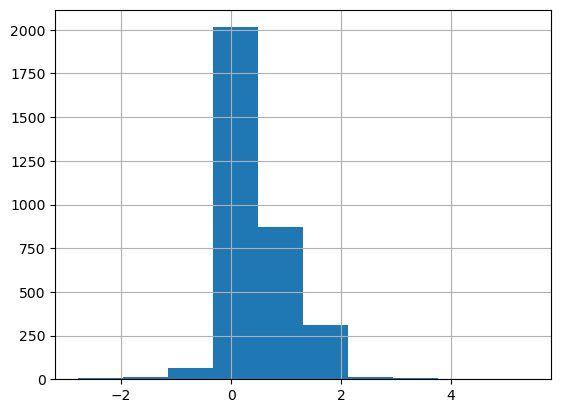

In [24]:
test_full['Pred_Closure'].hist();

In [38]:
test_full[['Facility Name','Pred_Closure','Year','Status','Time']].sort_values(by='Pred_Closure',ascending=False)

,Facility Name,Pred_Closure,Year,Status,Time
759,COVENANT HEALTH HOBBS HOSPITAL,5.412220,2024,False,16.0
464,CARILION TAZEWELL COMMUNITY HOSPITAL,4.934694,2024,False,16.0
465,CARILION TAZEWELL COMMUNITY HOSPITAL,4.898533,2025,False,16.0
463,CARILION TAZEWELL COMMUNITY HOSPITAL,4.444290,2023,False,16.0
877,ENNIS REGIONAL MEDICAL CENTER,4.349703,2022,False,16.0
...,...,...,...,...,...
527,CHELSEA HOSPITAL,-2.167884,2023,False,16.0
526,CHELSEA HOSPITAL,-2.189900,2022,False,16.0
2916,TWELVE CLANS UNITY HOSPITAL,-2.209091,2022,False,16.0
1187,HAZARD ARH REGIONAL MEDICAL CENTER,-2.330800,2023,False,16.0


Extracting feature coefficients to see exactly how much each feature increases or decreases the log-hazard risk. A positive coefficient indicates a higher risk of hospital closure, while a negative coefficient indicates a protective effect.

In [57]:
feature_cols = [col for col in test.columns if col not in ('CCN','Pred_Closure','Status','Time')]

feature_coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[:, 15] 
})

# Filter to see only the non-zero selected features
selected_features = feature_coef_df[feature_coef_df['Coefficient'] != 0]

In [59]:
pd.set_option('display.max_colwidth', None)
selected_features.sort_values(by='Coefficient').reset_index()

,index,Feature,Coefficient
0,115,Hospital Type_Voluntary non-profit - Private,-1.893385
1,78,Per Capita Short Term Gen Hosp Admissions,-1.455957
2,67,Dist Hosp By 00 - 39% Util Rate Short Term General Hospitals,-0.528233
3,82,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,-0.410298
4,48,Financial Indicators: SOLVENCY Equity Ratio,-0.162139
5,61,overall_score,-0.118510
6,100,Metro_Status_Metropolitan Statistical Area,-0.067989
7,54,rrate,-0.015910
8,59,help_score,0.034842
9,0,Year,0.157285


In [67]:
feature_cols = [col for col in test.columns if col not in ('CCN','Closure Proximity','Status','Time','Pred_Closure')]
X_test = test[feature_cols]
y_test = test[['Status','Time']]

In [69]:
# Wrap the scoring metric for the scikit-learn API
def c_index_scorer(model, X, y):
    # Coxnet predict returns risk scores; higher scores mean higher risk
    predictions = model.predict(X)
    
    # Scikit-survival expects structured array 'y' with event indicator and time
    # (Unpack the structured array fields based on your data structure, e.g., 'event', 'time')
    event_indicator = y['Status']
    event_time = y['Time']
    
    c_index, _, _, _, _ = concordance_index_censored(event_indicator, event_time, predictions)
    
    return c_index

# Permutation importance applied to the CoxnetSurvivalAnalysis model
feature_importances = permutation_importance(
    model, 
    X_test, 
    y_test,
    #Surv.from_arrays(y_test['Status'], y_test['Time']), 
    random_state=0, 
    scoring=c_index_scorer,
    n_repeats=5 
)

# Create the results DataFrame
top_features_df = pd.DataFrame({
    'variable': feature_cols,
    'importance': feature_importances['importances_mean']
}).sort_values('importance', ascending=False)

print(top_features_df.head())


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/uti

                                         variable  importance
115  Hospital Type_Voluntary non-profit - Private    0.130262
78      Per Capita Short Term Gen Hosp Admissions    0.069453
58                                  explain_score    0.051696
3            ADJUSTED SALARIES, Subtotal Salaries    0.044180
64                                recommend_score    0.027390


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetSurvivalAnalysis was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/uti

In [ ]:
# Plotting features by average shap score
explainer = shap.TreeExplainer(model)
explanation = explainer(X_test)
explanation.feature_names = pipe.get_feature_names_out()
# Visualize feature impact for the middle class (the class we are trying to predict)
shap.plots.bar(explanation[:, :, 1])